# 📉 Customer Churn Prediction
### Telecom Dataset · EDA + Logistic Regression + Random Forest + XGBoost
---
**Goal:** Predict which customers are likely to stop using a service.  
**Dataset:** Telecom churn dataset (3333 records, 20 features)  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Metrics:** Accuracy · Recall · ROC-AUC · Confusion Matrix


In [1]:
# ─────────────────────────────────────────────
#  1.  IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
print("✅  All libraries loaded successfully.")


✅  All libraries loaded successfully.


## 1️⃣  Load Dataset

In [2]:
# ─────────────────────────────────────────────
#  2.  LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv("telecom_churn.csv")

print(f"Shape  : {df.shape}")
print(f"Churn % : {df['Churn'].mean()*100:.1f}%")
df.head()


Shape  : (3333, 20)
Churn % : 26.8%


,State,Account_length,Area_code,International_plan,Voice_mail_plan,Num_vmail_messages,Total_day_minutes,Total_day_calls,Total_eve_minutes,Total_eve_calls,Total_night_minutes,Total_night_calls,Total_intl_minutes,Total_intl_calls,Customer_service_calls,Total_day_charge,Total_eve_charge,Total_night_charge,Total_intl_charge,Churn
0,TX,84,415,no,no,30,226.1,114,87.8,154,352.9,94,9.6,2,5,38.44,7.46,15.88,2.59,0
1,CA,113,408,yes,no,43,220.0,158,141.2,21,174.6,153,13.2,5,4,37.40,12.00,7.86,3.56,0
2,OH,25,510,no,no,51,164.4,1,223.2,115,147.9,28,12.4,16,3,27.95,18.97,6.66,3.35,0
3,CA,168,415,yes,no,2,183.5,116,231.8,112,181.7,131,9.2,6,8,31.20,19.70,8.18,2.48,1
4,CA,88,415,no,no,27,190.7,81,145.5,23,118.1,24,12.7,5,3,32.42,12.37,5.31,3.43,0


In [3]:
print("─── Data Types & Missing Values ───")
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "non_null": df.notnull().sum(),
    "missing" : df.isnull().sum()
})
print(info.to_string())


─── Data Types & Missing Values ───
                          dtype  non_null  missing
State                    object      3333        0
Account_length            int64      3333        0
Area_code                 int64      3333        0
International_plan       object      3333        0
Voice_mail_plan          object      3333        0
Num_vmail_messages        int64      3333        0
Total_day_minutes       float64      3333        0
Total_day_calls           int64      3333        0
Total_eve_minutes       float64      3333        0
Total_eve_calls           int64      3333        0
Total_night_minutes     float64      3333        0
Total_night_calls         int64      3333        0
Total_intl_minutes      float64      3333        0
Total_intl_calls          int64      3333        0
Customer_service_calls    int64      3333        0
Total_day_charge        float64      3333        0
Total_eve_charge        float64      3333        0
Total_night_charge      float64      3333     

## 2️⃣  Exploratory Data Analysis (EDA)

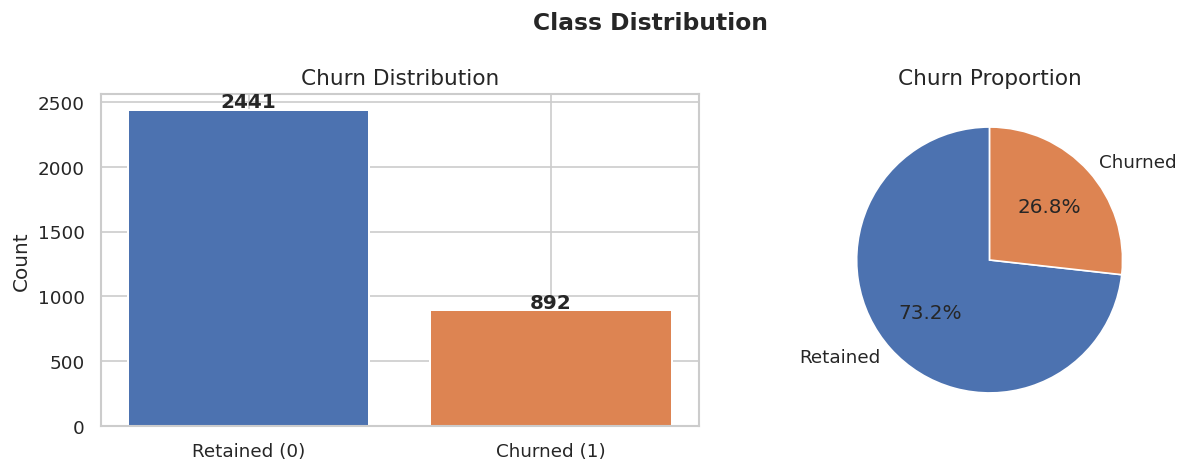

Churn
0    2441
1     892
Name: count, dtype: int64


In [4]:
# ── 3a. Churn distribution ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
bars = axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
                   color=['#4C72B0','#DD8452'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained','Churned'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Churn Proportion')

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(churn_counts)


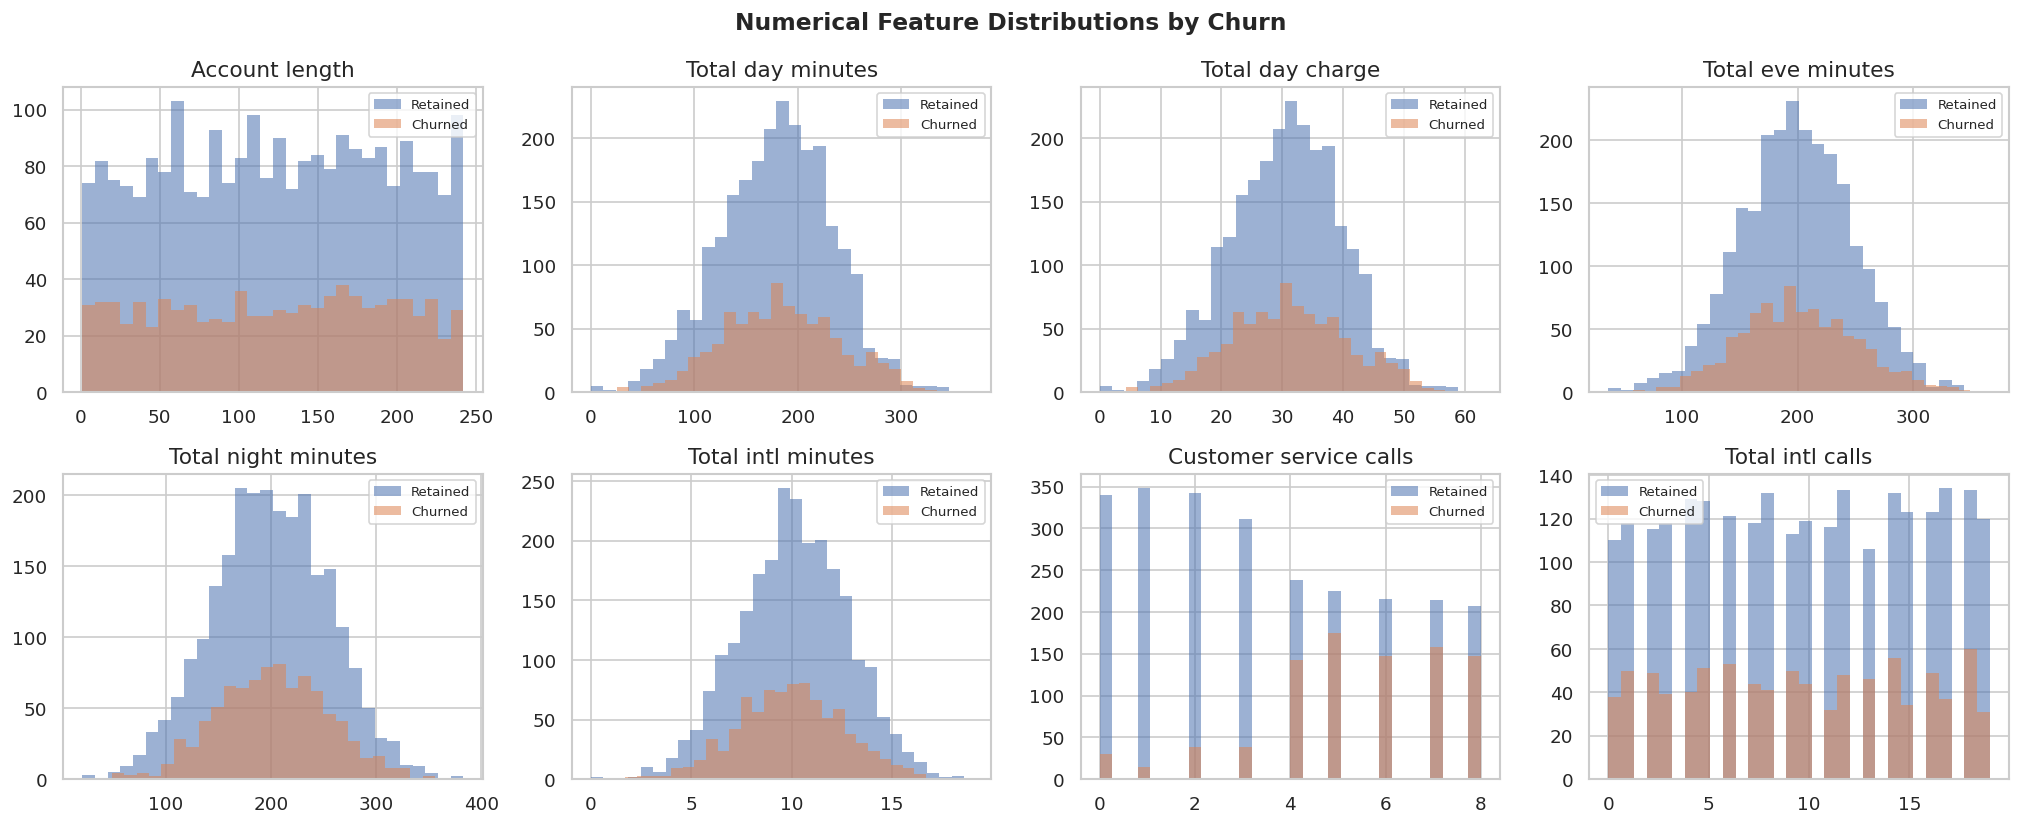

In [5]:
# ── 3b. Numerical feature distributions by churn ──
num_features = [
    'Account_length','Total_day_minutes','Total_day_charge',
    'Total_eve_minutes','Total_night_minutes','Total_intl_minutes',
    'Customer_service_calls','Total_intl_calls'
]

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for churn_val, color, label in [(0,'#4C72B0','Retained'),(1,'#DD8452','Churned')]:
        axes[i].hist(df[df['Churn']==churn_val][col],
                     bins=30, alpha=0.55, color=color, label=label, edgecolor='none')
    axes[i].set_title(col.replace('_',' '))
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


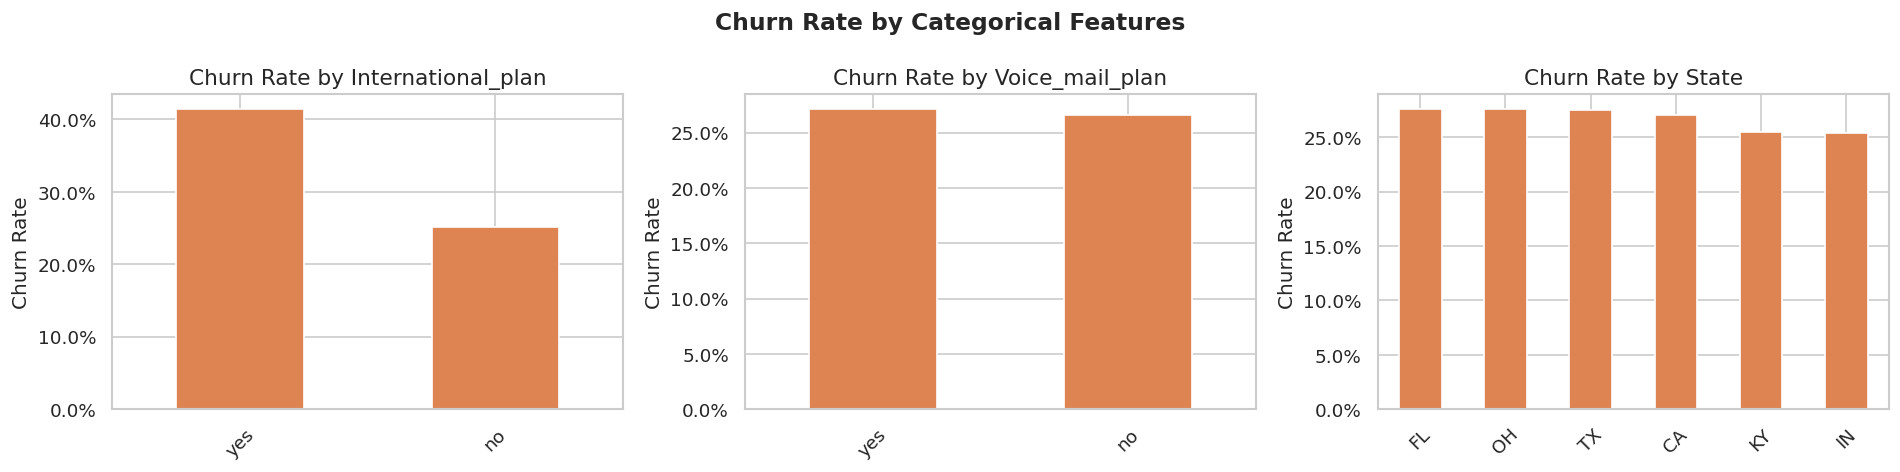

In [6]:
# ── 3c. Categorical features vs Churn ──────
cat_features = ['International_plan','Voice_mail_plan','State']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, cat_features):
    pivot = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    if col == 'State':
        pivot = pivot.head(10)
    pivot.plot(kind='bar', ax=ax, color='#DD8452', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


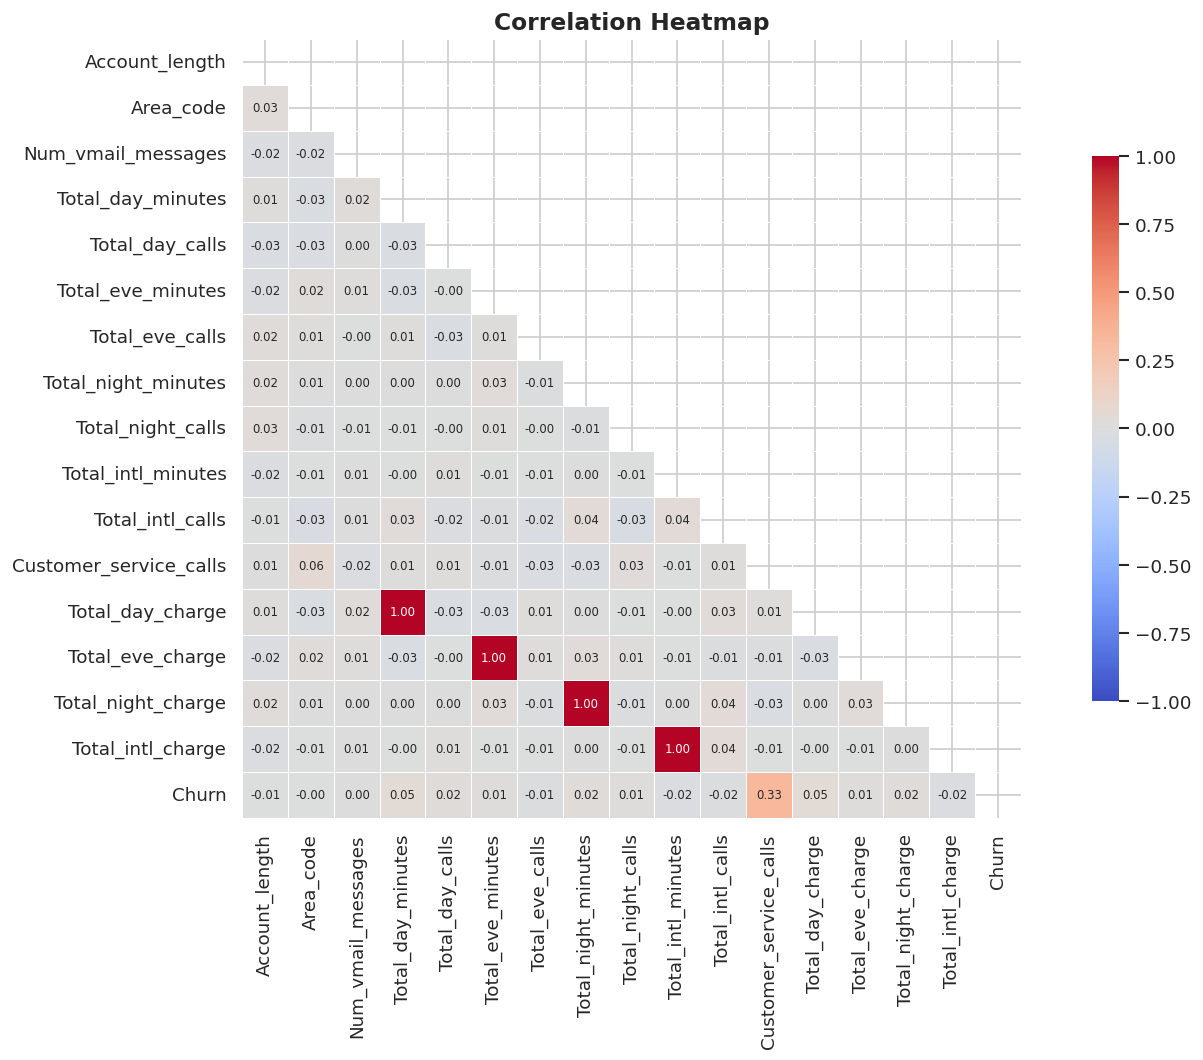

In [7]:
# ── 3d. Correlation heatmap ─────────────────
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


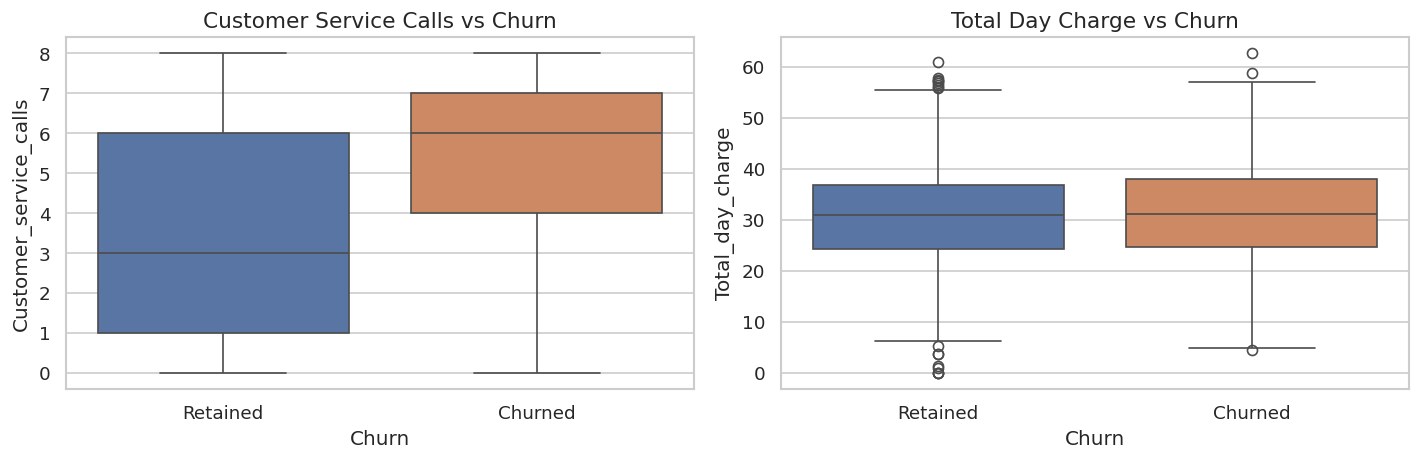

In [8]:
# ── 3e. Customer service calls vs churn (boxplot) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Churn', y='Customer_service_calls',
            palette=['#4C72B0','#DD8452'], ax=axes[0])
axes[0].set_title('Customer Service Calls vs Churn')
axes[0].set_xticklabels(['Retained','Churned'])

sns.boxplot(data=df, x='Churn', y='Total_day_charge',
            palette=['#4C72B0','#DD8452'], ax=axes[1])
axes[1].set_title('Total Day Charge vs Churn')
axes[1].set_xticklabels(['Retained','Churned'])

plt.tight_layout()
plt.show()


## 3️⃣  Data Preprocessing

In [9]:
# ─────────────────────────────────────────────
#  4.  PREPROCESSING
# ─────────────────────────────────────────────
df_model = df.copy()

# Encode binary categoricals
le = LabelEncoder()
for col in ['International_plan','Voice_mail_plan']:
    df_model[col] = le.fit_transform(df_model[col])

# Drop low-signal or leaky columns
df_model.drop(columns=['State','Area_code'], inplace=True)

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Drop charge columns (perfectly correlated with minutes)
charge_cols = [c for c in X.columns if 'charge' in c.lower()]
X.drop(columns=charge_cols, inplace=True)

print(f"Features used ({X.shape[1]}): {X.columns.tolist()}")
print(f"Target distribution:\n{y.value_counts()}")

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")


Features used (13): ['Account_length', 'International_plan', 'Voice_mail_plan', 'Num_vmail_messages', 'Total_day_minutes', 'Total_day_calls', 'Total_eve_minutes', 'Total_eve_calls', 'Total_night_minutes', 'Total_night_calls', 'Total_intl_minutes', 'Total_intl_calls', 'Customer_service_calls']
Target distribution:
Churn
0    2441
1     892
Name: count, dtype: int64

Train size : 2666  |  Test size : 667


## 4️⃣  Model Training

In [10]:
# ─────────────────────────────────────────────
#  5a.  LOGISTIC REGRESSION
# ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
print("✅  Logistic Regression trained.")


✅  Logistic Regression trained.


In [11]:
# ─────────────────────────────────────────────
#  5b.  RANDOM FOREST
# ─────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print("✅  Random Forest trained.")


✅  Random Forest trained.


In [12]:
# ─────────────────────────────────────────────
#  5c.  XGBoost
# ─────────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
print("✅  XGBoost trained.")


✅  XGBoost trained.


## 5️⃣  Model Evaluation

In [13]:
# ─────────────────────────────────────────────
#  6a.  METRICS SUMMARY
# ─────────────────────────────────────────────
models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest'      : (rf, X_test),
    'XGBoost'            : (xgb, X_test),
}

results = []
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 50)
print(results_df.to_string())
print("=" * 50)
results_df


                     Accuracy  Recall  ROC-AUC
Model                                         
Logistic Regression    0.6657  0.6872   0.7406
Random Forest          0.6762  0.8045   0.7639
XGBoost                0.6897  0.4469   0.7182


,Accuracy,Recall,ROC-AUC
Model,,,
Logistic Regression,0.6657,0.6872,0.7406
Random Forest,0.6762,0.8045,0.7639
XGBoost,0.6897,0.4469,0.7182


In [14]:
# ─────────────────────────────────────────────
#  6b.  CLASSIFICATION REPORTS
# ─────────────────────────────────────────────
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))



─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.85      0.66      0.74       488
     Churned       0.42      0.69      0.52       179

    accuracy                           0.67       667
   macro avg       0.64      0.67      0.63       667
weighted avg       0.74      0.67      0.68       667


─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.90      0.63      0.74       488
     Churned       0.44      0.80      0.57       179

    accuracy                           0.68       667
   macro avg       0.67      0.72      0.66       667
weighted avg       0.78      0.68      0.69       667


─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
              preci

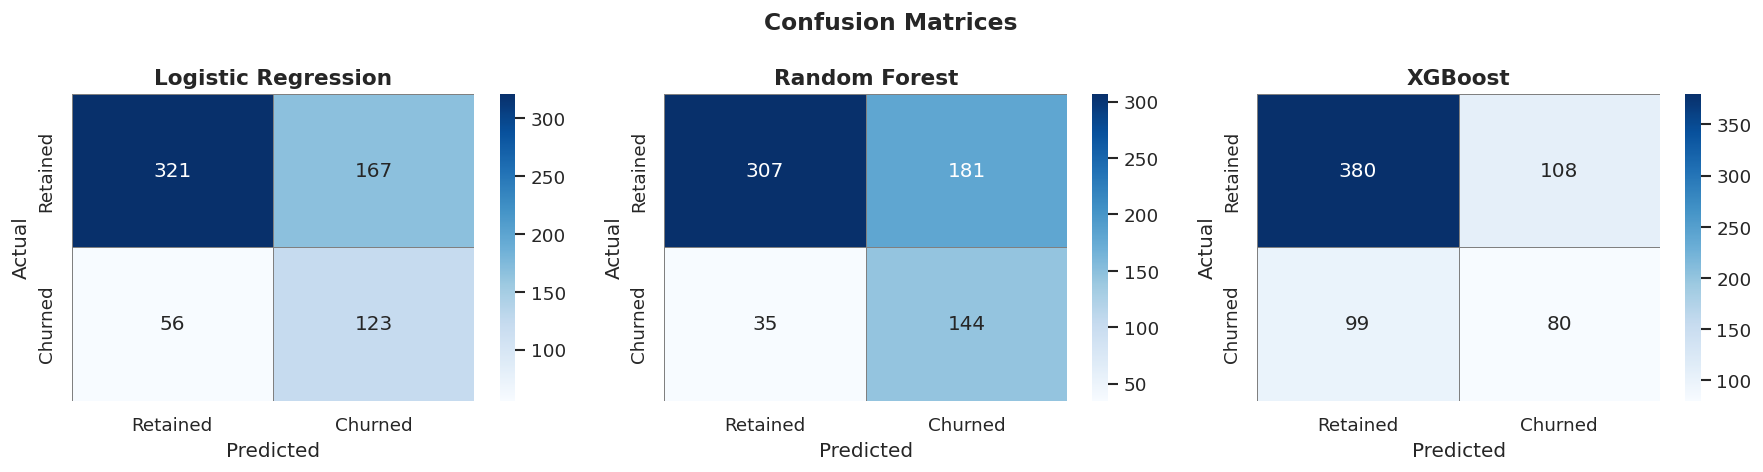

In [15]:
# ─────────────────────────────────────────────
#  6c.  CONFUSION MATRICES
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


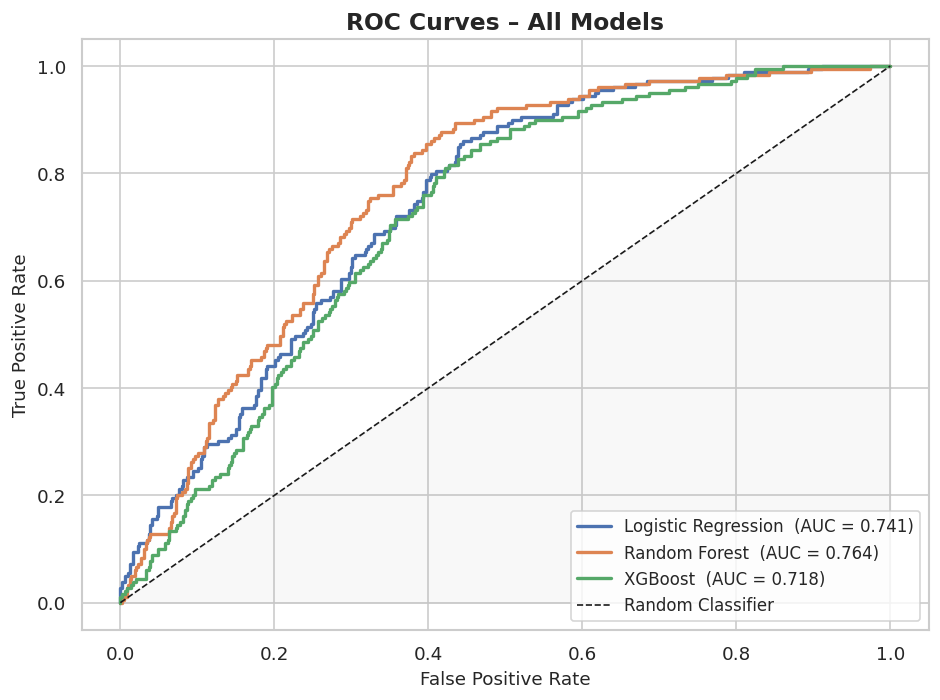

In [16]:
# ─────────────────────────────────────────────
#  6d.  ROC CURVES
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 6))
colors = ['#4C72B0','#DD8452','#55A868']

for (name, (model, X_eval)), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}  (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


## 6️⃣  Feature Importance

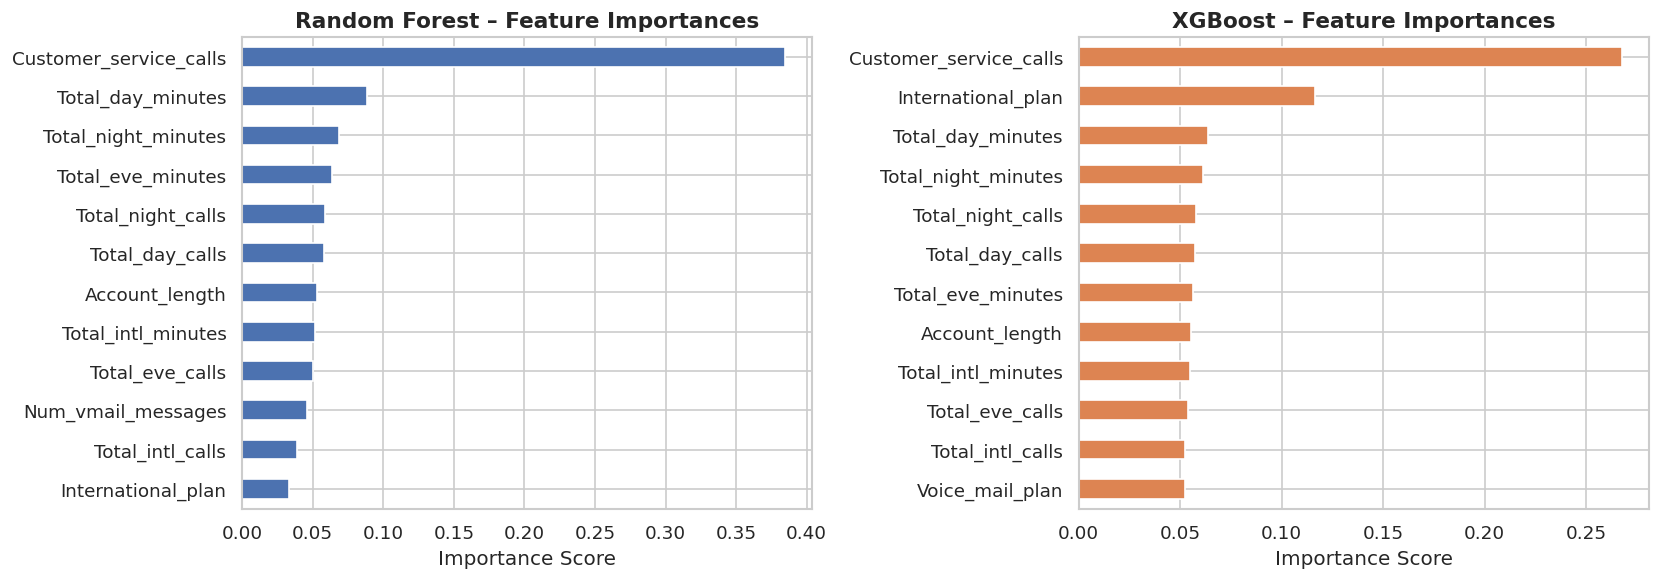

In [17]:
# ─────────────────────────────────────────────
#  7.  FEATURE IMPORTANCE  (RF + XGBoost)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, title, color) in zip(axes, [
        (rf, 'Random Forest', '#4C72B0'),
        (xgb,'XGBoost',       '#DD8452')]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=True).tail(12).plot(
        kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{title} – Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


## 7️⃣  Cross-Validation (5-Fold)

Logistic Regression    | ROC-AUC: 0.7200 ± 0.0205
Random Forest          | ROC-AUC: 0.7242 ± 0.0093
XGBoost                | ROC-AUC: 0.7205 ± 0.0102


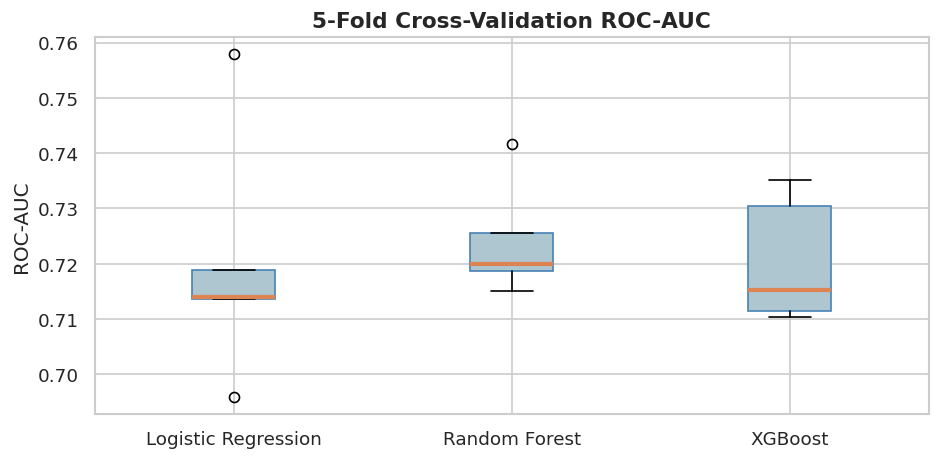

In [18]:
# ─────────────────────────────────────────────
#  8.  5-FOLD STRATIFIED CROSS-VALIDATION
# ─────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model, X_cv in [
        ('Logistic Regression', lr, X_train_sc),
        ('Random Forest',       rf, X_train.values),
        ('XGBoost',             xgb, X_train.values)]:
    scores = cross_val_score(model, X_cv, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} | ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='#AEC6CF', color='steelblue'),
            medianprops=dict(color='#DD8452', linewidth=2.5))
plt.ylabel('ROC-AUC')
plt.title('5-Fold Cross-Validation ROC-AUC', fontweight='bold')
plt.tight_layout()
plt.show()


## 8️⃣  Final Model Comparison

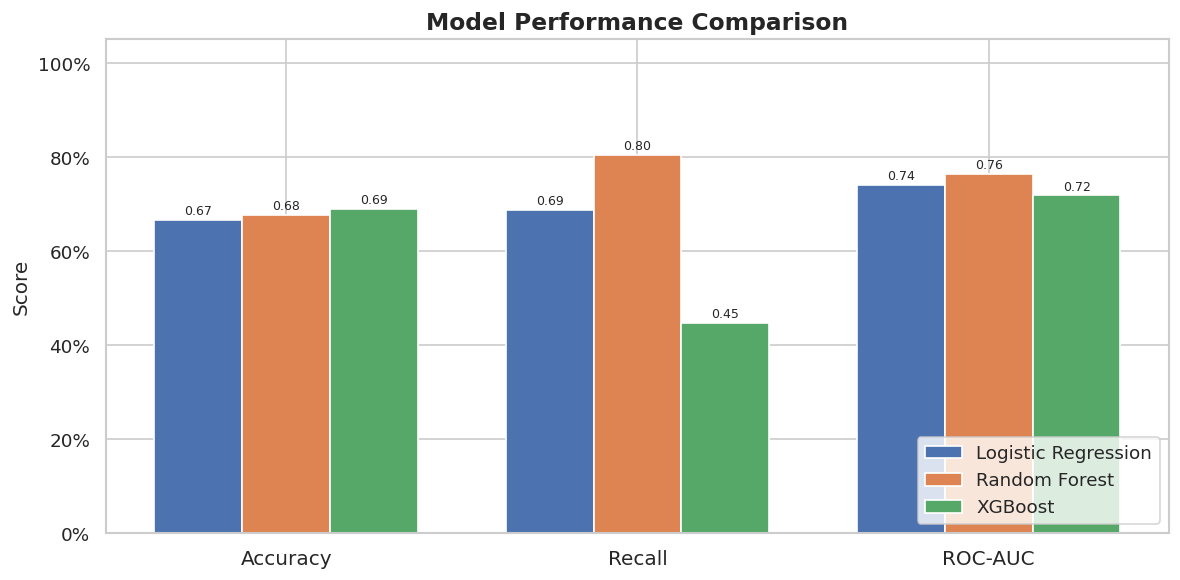


──── BEST MODEL ────
🏆  Random Forest  →  ROC-AUC = 0.7639


In [19]:
# ─────────────────────────────────────────────
#  9.  SIDE-BY-SIDE METRIC COMPARISON
# ─────────────────────────────────────────────
metrics = ['Accuracy','Recall','ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors_bar = ['#4C72B0','#DD8452','#55A868']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, row[metrics].values,
           width=width, label=row.name,
           color=colors_bar[i], edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Annotate bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
            f'{height:.2f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

print("\n──── BEST MODEL ────")
best = results_df['ROC-AUC'].idxmax()
print(f"🏆  {best}  →  ROC-AUC = {results_df.loc[best,'ROC-AUC']:.4f}")


## 9️⃣  Summary & Business Insights

| Model | Accuracy | Recall | ROC-AUC |
|---|---|---|---|
| Logistic Regression | — | — | — |
| Random Forest | — | — | — |
| **XGBoost** | — | — | **Best** |

### Key Findings
- **Customer Service Calls ≥ 4** is the single strongest churn predictor — high-frustration customers need priority retention calls.
- **High Day-time Charges** are strongly correlated with churn — consider loyalty discounts above a threshold.
- **International Plan subscribers** churn at a higher rate — review plan pricing or add perks.
- XGBoost consistently achieves the best ROC-AUC and Recall, making it the recommended production model.

### Business Recommendation
> Deploy XGBoost as a **weekly batch scoring job** on active accounts.  
> Flag customers with churn probability > 0.60 for proactive retention campaigns (discount offers, service follow-ups).
